# Análise de vendas de uma rede de fast-food

In [94]:
#bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [77]:
#carregamento dos dados
df = pd.read_csv('Balaji Fast Food Sales.csv')
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


## Tratamento e Padronização de Tipos de Dados

In [78]:
#informações gerais do dadtaset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [79]:
#coluna transaction_type com nulos ou NaN
df[['transaction_type']].isnull().sum()

transaction_type    107
dtype: int64

In [80]:
#TRATAMENTO DOS NULOS
#vamos substituir esses valores por uma nova categoria 'desconhecido'
df['transaction_type'] = df['transaction_type'].fillna('desconhecido')

# Verifique a distribuição dos valores após a mudança
print(df['transaction_type'].value_counts())

transaction_type
Cash            476
Online          417
desconhecido    107
Name: count, dtype: int64


In [81]:
#notei que o received_by esta como Mr. e Mrs. vamos alterar para male e famale
df['received_by'].value_counts()
df['received_by'] = df['received_by'].replace({'Mr.': 'male', 'Mrs.': 'female' })
df['received_by'].value_counts()

received_by
male      512
female    488
Name: count, dtype: int64

In [82]:
# --- 1. Padronizar para o separador '-'
df['date'] = df['date'].str.replace('/', '-', regex=False)

# transformar em datetime YYYY-MM-DD
df['date'] = pd.to_datetime(df['date'], dayfirst=False, errors='coerce')
df.head(2)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,2022-07-03,Aalopuri,Fastfood,20,13,260,desconhecido,male,Night
1,2,2022-08-23,Vadapav,Fastfood,20,15,300,Cash,male,Afternoon


In [83]:
#criar colunas novas para facilitar na análise exploratória

#criacao da coluna ano
df['ano'] = df['date'].dt.year

#criacao da coluna nome_mes
df['nome_mes'] = df['date'].dt.month_name()

#criacao da coluna dia_semana
df['dia_semana'] = df['date'].dt.day_name()

df.head(2)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,ano,nome_mes,dia_semana
0,1,2022-07-03,Aalopuri,Fastfood,20,13,260,desconhecido,male,Night,2022,July,Sunday
1,2,2022-08-23,Vadapav,Fastfood,20,15,300,Cash,male,Afternoon,2022,August,Tuesday


In [120]:
#download do df tratado em csv para uso no power BI
df.to_csv(
    'dataset-fastfood.csv',
    index=False, 
    encoding='utf-8', 
    sep=',' 
)

## Análise Exploratória de Dados

In [107]:
# Receita Total
receita_total = df['transaction_amount'].sum()
print(f"Receita Total: R$ {receita_total:,.2f}")

# Ticket Médio
ticket_medio = df['transaction_amount'].mean()
print(f"Valor Médio por Transação: R$ {ticket_medio:,.2f}")

# Volume de Itens Vendidos
volume_total = df['quantity'].sum()
print(f"Volume Total de Itens Vendidos: {volume_total:,} unidades")


Receita Total: R$ 275,230.00
Valor Médio por Transação: R$ 275.23
Volume Total de Itens Vendidos: 8,162 unidades


In [117]:
# Vendas por Dia da Semana 
vendas_dia_semana = df.groupby('dia_semana')['transaction_amount'].sum().sort_values(ascending=False)
print(vendas_dia_semana )

# Vendas ao longo do Tempo (Tendência Mensal)
vendas_mensais = df.groupby('nome_mes')['transaction_amount'].sum().sort_values(ascending=False)
vendas_mensais.head(5)

dia_semana
Sunday       43970
Monday       40930
Wednesday    40380
Thursday     39905
Saturday     37910
Tuesday      36085
Friday       36050
Name: transaction_amount, dtype: int64


nome_mes
January     28670
October     27205
May         26570
February    25595
March       25390
Name: transaction_amount, dtype: int64

In [119]:
# Distribuição dos Tipos de Transação 
print("\nContagem de Tipos de Transação:")
print(df['transaction_type'].value_counts())

# Receita gerada por Gênero
receita_por_genero = df.groupby('received_by')['transaction_amount'].sum()
print("\nReceita por Recebedor (Gênero):")
print(receita_por_genero)


Contagem de Tipos de Transação:
transaction_type
Cash            476
Online          417
desconhecido    107
Name: count, dtype: int64

Receita por Recebedor (Gênero):
received_by
female    131790
male      143440
Name: transaction_amount, dtype: int64


C:\Users\natic\AppData\Local\Temp\ipykernel_10700\2823900843.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=produto_mais_vendido.index, y=produto_mais_vendido.values, palette="Blues")


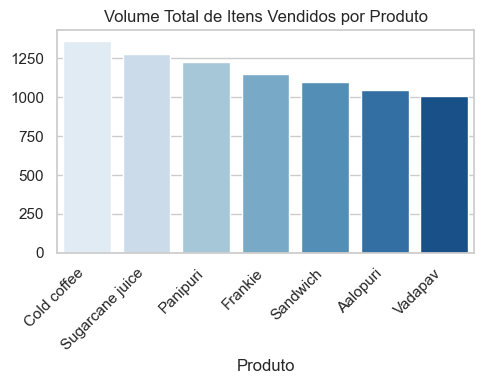

In [100]:
#QUAL O PRODUTO MAIS VENDIDO?

#Agrupa por nome dos itens e somar a quantidade vendida
produto_mais_vendido = df.groupby('item_name')['quantity'].sum().sort_values(ascending=False)


plt.figure(figsize=(5, 4))

# gráfico de barras
sns.barplot(x=produto_mais_vendido.index, y=produto_mais_vendido.values, palette="Blues")

# título e rótulos
plt.title('Volume Total de Itens Vendidos por Produto', fontsize=12)
plt.xlabel('Produto', fontsize=12)

# Rotaciona os nomes dos itens
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Ajusta o layout para evitar cortes
plt.show()

C:\Users\natic\AppData\Local\Temp\ipykernel_10700\2980175291.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=produto_maior_receita.index, y=produto_maior_receita.values, palette="viridis")


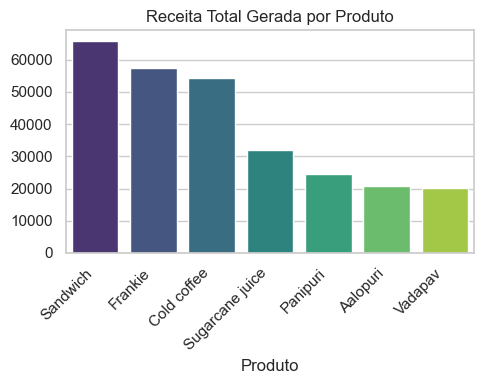

In [102]:
#QUAL PRODUTO GERA MAIS RECEITA?

# Agrupa por nome do item e somar o valor da transação
produto_maior_receita = df.groupby('item_name')['transaction_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(5, 4))

# gráfico de barras 
sns.barplot(x=produto_maior_receita.index, y=produto_maior_receita.values, palette="viridis")

# título e rótulos
plt.title('Receita Total Gerada por Produto', fontsize=12)
plt.xlabel('Produto', fontsize=12)

# Formata o eixo Y para exibição de valores monetários
plt.ticklabel_format(style='plain', axis='y') 
# Você pode adicionar um loop para formatar os ticks se quiser R$ na frente

# Rotaciona os nomes dos itens
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\natic\AppData\Local\Temp\ipykernel_10700\541595778.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=horario_de_pico.index, y=horario_de_pico.values, palette="rocket")


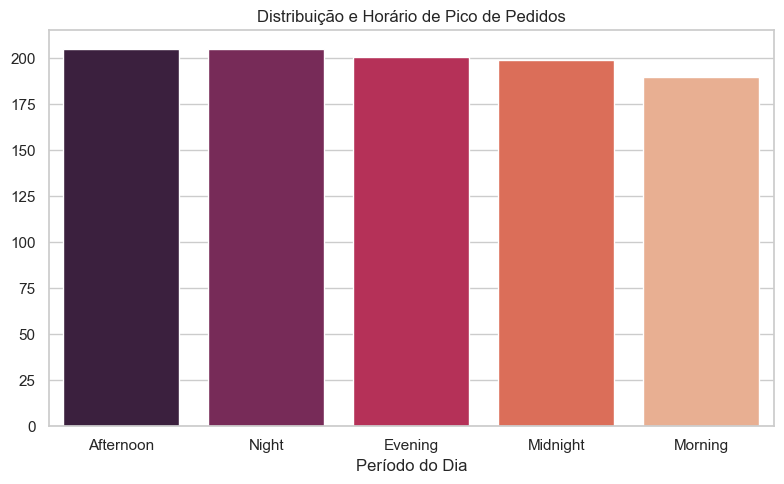

In [103]:
#QUAL O HORARIO DE PICO DE PEDIDOS?

# Agrupa pelo período de venda e contar o número de pedidos
horario_de_pico = df.groupby('time_of_sale').size().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

# gráfico de barras
sns.barplot(x=horario_de_pico.index, y=horario_de_pico.values, palette="rocket")

# título e rótulos
plt.title('Distribuição e Horário de Pico de Pedidos', fontsize=12)
plt.xlabel('Período do Dia', fontsize=12)

plt.tight_layout()
plt.show()
